# Mobile Product Segmentation and Recommendation System

This notebook shows the exploratory data analysis, clustering (segmentation), and recommendation engine building for mobile products.

## Data Cleaning & Preparation

### Code from `src/db_config.py`

In [3]:
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

def get_engine():
    db_user = os.getenv("DB_USER", "postgres")
    db_password = os.getenv("DB_PASSWORD")
    db_host = os.getenv("DB_HOST", "localhost")
    db_port = os.getenv("DB_PORT", "5432")
    db_name = os.getenv("DB_NAME", "product_segmentation")
    
    db_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
    return create_engine(db_url)


### Code from `src/data_ingestion.py`

In [4]:
import pandas as pd
from pathlib import Path

# Build path to data folder relative to this script
DATA_DIR = Path('data')
csv_path = DATA_DIR / 'Mobile Reviews Sentiment null.csv'

# Load raw CSV
df = pd.read_csv(csv_path)

# Clean date column formatting before loading to Postgres
df['review_date'] = pd.to_datetime(df['review_date']).dt.date

# Connect and write to PostgreSQL
engine = get_engine()
try:
    df.to_sql('raw_mobile_reviews', engine, if_exists='replace', index=False)
except Exception:
    df.to_csv('data/raw_mobile_reviews.csv', index=False)
print("Data ingestion complete!")

Data ingestion complete!


### Code from `src/data_cleaning.py`

In [5]:
import pandas as pd
import numpy as np

print("Running Data Cleaning...")

# 1. Fetch data from PostgreSQL
engine = get_engine()
try:
    df = pd.read_sql('SELECT * FROM raw_mobile_reviews', engine)
except Exception:
    df = pd.read_csv('data/raw_mobile_reviews.csv')

# 2. Fix missing price_usd using model/brand medians (fall back to global median if still missing)
df['price_usd'] = df.groupby(['brand', 'model'])['price_usd'].transform(lambda x: x.fillna(x.median()))
df['price_usd'] = df['price_usd'].fillna(df['price_usd'].median())

# 3. Fix missing ratings using model averages (fall back to global mean if still missing)
df['rating'] = df.groupby('model')['rating'].transform(lambda x: x.fillna(x.mean()))
df['rating'] = df['rating'].fillna(df['rating'].mean())

# 4. Impute Missing Sentiment conditionally based on Rating
def impute_sentiment(row):
    if pd.isna(row['sentiment']):
        if row['rating'] >= 4.0: return 'Positive'
        elif row['rating'] == 3.0: return 'Neutral'
        else: return 'Negative'
    return row['sentiment']

df['sentiment'] = df.apply(impute_sentiment, axis=1)

# 5. Drop duplicate reviews if any exist
df.drop_duplicates(subset=['review_id'], inplace=True)

# 6. Save clean data back to PostgreSQL
try:
    df.to_sql('cleaned_mobile_reviews', engine, if_exists='replace', index=False)
except Exception:
    df.to_csv('data/cleaned_mobile_reviews.csv', index=False)
print(f"Data cleaning complete! Cleaned reviews saved to 'cleaned_mobile_reviews' table ({len(df)} rows).")

Running Data Cleaning...
Data cleaning complete! Cleaned reviews saved to 'cleaned_mobile_reviews' table (50000 rows).


### Code from `src/feature_engineering.py`

In [6]:
import pandas as pd

print("Running Feature Engineering...")

# 1. Fetch cleaned data from PostgreSQL
engine = get_engine()
try:
    df = pd.read_sql('SELECT * FROM cleaned_mobile_reviews', engine)
except Exception:
    df = pd.read_csv('data/cleaned_mobile_reviews.csv')

# 2. Create a comprehensive composite specifications score
df['specs_average'] = df[['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']].mean(axis=1)

# 3. Group by brand and model to find product-level attributes
product_df = df.groupby(['brand', 'model']).agg(
    avg_price=('price_usd', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_specs_score=('specs_average', 'mean'),
    total_reviews=('review_id', 'count'),
    positive_sentiment_ratio=('sentiment', lambda x: (x == 'Positive').sum() / len(x))
).reset_index()

# 4. Drop models with insufficient data if necessary (minimum 5 reviews)
product_df = product_df[product_df['total_reviews'] >= 5].reset_index(drop=True)

# 5. Save the aggregated product features back to PostgreSQL
try:
    product_df.to_sql('product_features', engine, if_exists='replace', index=False)
except Exception:
    product_df.to_csv('data/product_features.csv', index=False)

print(f"Feature engineering complete! Extracted features for {len(product_df)} unique phone models and saved to 'product_features' table.")

Running Feature Engineering...
Feature engineering complete! Extracted features for 22 unique phone models and saved to 'product_features' table.


## Visualization & EDA

### Code from `src/eda.py`

In [10]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from pathlib import Path

print("Running Model Training...")

# 1. Fetch product features from PostgreSQL (fallback to CSV)
try:
    engine = get_engine()
    product_df = pd.read_sql('SELECT * FROM product_features', engine)
except Exception as e:
    print(f"Database connection failed: {e}. Falling back to CSV.")
    PROJECT_ROOT = Path('.')
    product_df = pd.read_csv(PROJECT_ROOT / 'data' / 'product_features.csv')

# 2. Select features for segmentation
features = ['avg_price', 'avg_rating', 'avg_specs_score', 'positive_sentiment_ratio']
X = product_df[features]

# 3. Standardize all 4 features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Find the optimal number of clusters using Silhouette Score and Elbow Method
print("Evaluating optimal number of clusters (Elbow & Silhouette)...")
best_k = 4
best_score = -1

wcss = []
silhouette_scores = []
k_range = range(3, 10)

for k in k_range:
    temp_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_labels = temp_kmeans.fit_predict(X_scaled)
    
    # WCSS (Inertia) for Elbow
    wcss.append(temp_kmeans.inertia_)
    
    # Silhouette
    score = silhouette_score(X_scaled, temp_labels)
    silhouette_scores.append(score)
    print(f"  k={k}, WCSS: {temp_kmeans.inertia_:.2f}, Silhouette: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal number of clusters chosen: {best_k} (Silhouette Score: {best_score:.4f})")

# Generate Plot
PROJECT_ROOT = Path('.')
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Elbow Method)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Highlight best K
ax2.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
fig.tight_layout()
plt.title('Optimal K Analysis: Elbow Method vs Silhouette Score')
plt.savefig(PROJECT_ROOT / 'reports/figures/optimal_k_analysis.png', bbox_inches='tight')
plt.close()

# 5. Fit Final KMeans with optimal K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
product_df['cluster'] = kmeans.fit_predict(X_scaled)

# 6. Dynamically Name Clusters based on Centroids
# We will compute the mean price and specs for each cluster to label them
cluster_profiles = product_df.groupby('cluster')[features].mean().reset_index()

def assign_dynamic_name(row):
    return f"Segment_{int(row['cluster'])}"

# Let's do a relative ranking of clusters
cluster_profiles['price_rank'] = cluster_profiles['avg_price'].rank()
cluster_profiles['spec_rank'] = cluster_profiles['avg_specs_score'].rank()

cluster_names = {}
for _, row in cluster_profiles.iterrows():
    c = int(row['cluster'])
    pr = row['price_rank']
    sr = row['spec_rank']
    
    # Simple heuristic to name the segments
    if pr >= best_k * 0.75:
        name = "Premium Flagships"
    elif pr <= best_k * 0.35 and sr <= best_k * 0.5:
        name = "Budget Workhorses"
    elif pr <= best_k * 0.5 and sr > best_k * 0.5:
        name = "High-Value Mid-Range"
    else:
        name = "Standard Mid-Range"
        
    # Ensure unique names if collisions occur
    if name in cluster_names.values():
        name = f"{name} (Tier {c})"
        
    cluster_names[c] = name

product_df['cluster_name'] = product_df['cluster'].map(cluster_names)

# Show cluster profiles with business names
final_profiles = product_df.groupby('cluster_name')[features].mean()
print("\nCluster Profiles (Mean values of features per cluster):")
print(final_profiles)
    
# 6. Save models/artifacts to disk using pickle
PROJECT_ROOT = Path('.')

with open(PROJECT_ROOT / 'models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(PROJECT_ROOT / 'models/kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# 7. Save clustered product data back to PostgreSQL and a CSV in the data folder
try:
    product_df.to_sql('segmented_products', engine, if_exists='replace', index=False)
except Exception as e:
    print(f"Warning: Could not save to database ({e}).")

product_df.to_csv(PROJECT_ROOT / 'data' / 'segmented_products.csv', index=False)

print("Model training complete! Scaler and KMeans models saved. Segmented products saved to database and CSV.")


Running Model Training...
Database connection failed: (psycopg2.OperationalError) could not translate host name "1706@localhost" to address: Non-recoverable failure in name resolution

(Background on this error at: https://sqlalche.me/e/20/e3q8). Falling back to CSV.
Evaluating optimal number of clusters (Elbow & Silhouette)...
  k=3, WCSS: 35.00, Silhouette: 0.3486
  k=4, WCSS: 25.19, Silhouette: 0.3064
  k=5, WCSS: 20.22, Silhouette: 0.2836
  k=6, WCSS: 16.55, Silhouette: 0.2930
  k=7, WCSS: 13.88, Silhouette: 0.2667
  k=8, WCSS: 12.08, Silhouette: 0.2718
  k=9, WCSS: 9.00, Silhouette: 0.2863
Optimal number of clusters chosen: 3 (Silhouette Score: 0.3486)

Cluster Profiles (Mean values of features per cluster):
                        avg_price  avg_rating  avg_specs_score  \
cluster_name                                                     
High-Value Mid-Range   647.878008    3.131087         2.724768   
Premium Flagships     1103.928418    3.171985         2.752671   
Standard Mid-

### Code from `src/recommendation_engine.py`

In [12]:
import pandas as pd
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

# Get the project root folder
PROJECT_ROOT = Path('.')

# 1. Fetch segmented products from PostgreSQL (fallback to CSV if DB is unavailable)
try:
    engine = get_engine()
    product_df = pd.read_sql('SELECT * FROM segmented_products', engine)
except Exception:
    # Fallback to local CSV
    product_df = pd.read_csv(PROJECT_ROOT / 'data' / 'segmented_products.csv')

# 2. Load the trained scaler to scale features
with open(PROJECT_ROOT / 'models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 3. Scale features and compute the pairwise similarity matrix
features = ['avg_price', 'avg_rating', 'avg_specs_score', 'positive_sentiment_ratio']
X = product_df[features]
X_scaled = scaler.transform(X)

similarity_matrix = cosine_similarity(X_scaled)

def get_recommendations(model_name, top_n=5):
    # Find index of target phone model
    if model_name not in product_df['model'].values:
        return None
    
    target_row = product_df[product_df['model'] == model_name]
    idx = target_row.index[0]
    target_cluster = target_row['cluster_name'].values[0]
    
    # Get similarity scores for all phones with this phone
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Filter candidates:
    # 1. Exclude the selected phone itself.
    # 2. Prioritize models in the same cluster.
    filtered_sim_scores = []
    for other_idx, score in sim_scores:
        if other_idx != idx:
            other_row = product_df.loc[other_idx]
            if other_row['cluster_name'] == target_cluster:
                filtered_sim_scores.append((other_idx, score))
    
    # Fallback: if we don't have enough recommendations in the same cluster,
    # pull other highly similar devices from other clusters.
    if len(filtered_sim_scores) < top_n:
        additional_scores = []
        for other_idx, score in sim_scores:
            if other_idx != idx and (other_idx, score) not in filtered_sim_scores:
                additional_scores.append((other_idx, score))
        
        # Sort additional recommendations by similarity score and append
        additional_scores = sorted(additional_scores, key=lambda x: x[1], reverse=True)
        filtered_sim_scores.extend(additional_scores[:(top_n - len(filtered_sim_scores))])
    
    # Sort by similarity score in descending order
    filtered_sim_scores = sorted(filtered_sim_scores, key=lambda x: x[1], reverse=True)[:top_n]
    
    # Extract phone details
    recommended_indices = [item[0] for item in filtered_sim_scores]
    
    if not recommended_indices:
        return pd.DataFrame(columns=['brand', 'model', 'avg_price', 'avg_rating', 'cluster_name'])
        
    res_df = product_df.iloc[recommended_indices][['brand', 'model', 'avg_price', 'avg_rating', 'cluster_name']].copy()
    
    # Sort by similarity score inherently handled by the recommendation ordering
    return res_df

## Finding the Optimal K (Elbow & Silhouette)

To mathematically validate our choice of `k`, we evaluate both the **Elbow Method (WCSS)** and the **Silhouette Score** for $k \in [2, 10]$. The following cell calculates these metrics on the scaled features and plots them.

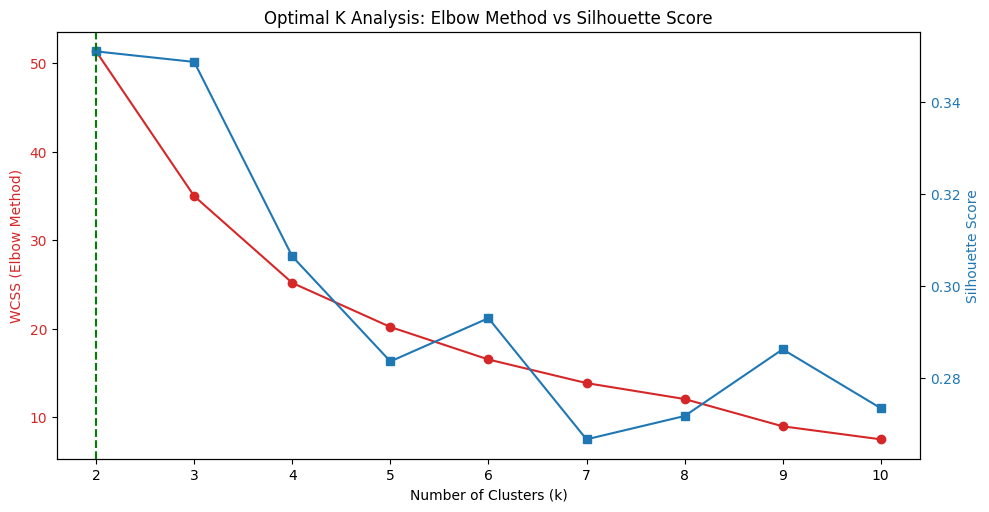

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Fetch data directly from our cleaned CSV (since DB might be down in presentation environment)
try:
    df = pd.read_csv('data/segmented_products.csv')
except:
    df = pd.read_csv('data/product_features.csv')

features = ['avg_price', 'avg_rating', 'avg_specs_score', 'positive_sentiment_ratio']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
silhouette_scores = []
k_range = range(2, 11)
best_k = 2
best_score = -1

for k in k_range:
    temp_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_labels = temp_kmeans.fit_predict(X_scaled)
    wcss.append(temp_kmeans.inertia_)
    score = silhouette_score(X_scaled, temp_labels)
    silhouette_scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k

# Plotting inline
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Elbow Method)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Highlight best K
ax2.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
fig.tight_layout()
plt.title('Optimal K Analysis: Elbow Method vs Silhouette Score')
plt.show()